# Notebook 2 – Behavioral Changes

**Question**: Do travelers adjust timing, routes, provider choice (Uber vs. taxi), or pickup/dropoff locations to avoid the congestion fee?

**Approach**:
- Bucket-level distributional comparisons (pre vs. post) for timing and provider.
- PCA on the origin-destination (OD) trip-count matrix to detect corridor-level route shifts.
- Random Forest classifier to rank behavioral drivers of CBD-zone entry, pre vs. post.

**Outline**
1. Load & Validate
2. Type Coercions
3. Timing Shifts by Hour Bucket
4. Provider Switching
5. PCA on Origin-Destination Matrix
6. Location Avoidance (Zone-Level % Change)
7. CBD Entry vs. Exit Patterns
8. Speed & Congestion by Bucket
9. Random Forest – CBD Zone Classifier
10. Feature Importance: Pre vs. Post Comparison
11. Conclusions

In [1]:
import gc
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd()))

from utils import (
    DATA_PATH,
    HOUR_BUCKET_ORDER,
    RANDOM_STATE,
    coerce_types,
    load_and_validate,
    pca_od_matrix,
)

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')

## 1. Load & Validate

In [2]:
REQUIRED_COLS = [
    'pickup_hour_of_day', 'pickup_day_of_week', 'in_cbd_zone',
    'dataset_split', 'provider', 'PULocationID', 'DOLocationID',
    'fare_amount', 'trip_distance', 'cost_per_mile', 'speed_mph',
    'temperature', 'precipitation', 'windspeed',
    'weather_clear', 'weather_cloudy', 'weather_rain',
    'airport_fee', 'cbd_congestion_fee',
]

df_raw = load_and_validate(DATA_PATH, REQUIRED_COLS)
df_raw.head(3)

Loaded 38,202,226 rows × 30 columns


,pickup_datetime,provider,dropoff_datetime,PULocationID,DOLocationID,trip_distance,trip_time,fare_amount,tax,tolls_amount,...,windspeed,weather_clear,weather_cloudy,weather_rain,weather_snow,dataset_split,pickup_day_of_week,pickup_hour_of_day,dropoff_day_of_week,dropoff_hour_of_day
0,2024-01-23 00:50:15,1,2024-01-23 01:21:53,132,33,26.62,1898,96.8,0.5,0.0,...,11.6,0,1,0,0.0,train,1,0,1,1
1,2024-01-14 20:21:20,1,2024-01-14 20:26:25,236,43,0.76,305,7.2,0.5,0.0,...,12.1,0,1,0,0.0,train,6,20,6,20
2,2024-01-23 00:23:16,1,2024-01-23 00:25:55,246,50,0.70,159,5.8,0.5,0.0,...,11.6,0,1,0,0.0,train,1,0,1,0


## 2. Type Coercions

In [3]:
df = coerce_types(df_raw)

df['PULocationID'] = df['PULocationID'].astype('Int64')
df['DOLocationID'] = df['DOLocationID'].astype('Int64')

print(f"Providers: {sorted(df['provider'].dropna().unique())}")
print(f"Pre rows : {(df['post']==0).sum():,}")
print(f"Post rows: {(df['post']==1).sum():,}")

del df_raw
gc.collect()

Providers: [np.int64(1), np.int64(2)]
Pre rows : 19,538,021
Post rows: 18,664,205


0

## 3. Timing Shifts by Hour Bucket

Do travelers shift their rides to off-peak windows to avoid the CBD fee?

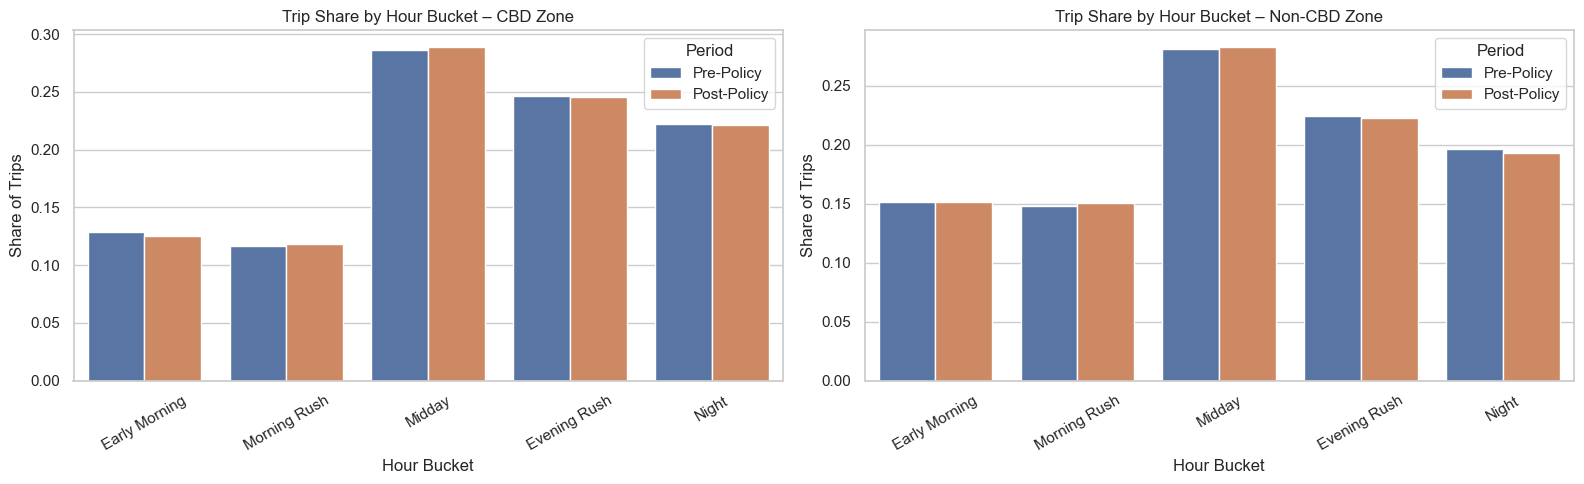

In [4]:
timing = (
    df.groupby(['post', 'in_cbd_zone', 'hour_bucket'], observed=True)
    .size()
    .rename('trip_count')
    .reset_index()
)

# Normalize to share within each (post, in_cbd_zone) group
timing['total'] = timing.groupby(['post', 'in_cbd_zone'])['trip_count'].transform('sum')
timing['share'] = timing['trip_count'] / timing['total']
timing['period_label'] = timing['post'].map({0: 'Pre-Policy', 1: 'Post-Policy'})
timing['zone_label'] = timing['in_cbd_zone'].map({True: 'CBD Zone', False: 'Non-CBD Zone'})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (zone_flag, zone_label) in zip(axes, [(True, 'CBD Zone'), (False, 'Non-CBD Zone')]):
    sub = timing[timing['in_cbd_zone'] == zone_flag]
    sns.barplot(
        data=sub, x='hour_bucket', y='share', hue='period_label',
        order=HOUR_BUCKET_ORDER, ax=ax
    )
    ax.set_title(f'Trip Share by Hour Bucket – {zone_label}', fontsize=12)
    ax.set_ylabel('Share of Trips')
    ax.set_xlabel('Hour Bucket')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Period')
plt.tight_layout()
plt.show()

In [ ]:
# Chi-square test: is the hour-bucket distribution different pre vs. post (within CBD)?
for zone_flag, zone_label in [(True, 'CBD Zone'), (False, 'Non-CBD Zone')]:
    contingency = (
        df[df['in_cbd_zone'] == zone_flag]
        .groupby(['post', 'hour_bucket'], observed=True)
        .size()
        .unstack('hour_bucket')
        .reindex(columns=HOUR_BUCKET_ORDER)
        .fillna(0)
    )
    chi2, p, dof, _ = chi2_contingency(contingency)
    print(f"{zone_label}: chi2={chi2:.1f}, df={dof}, p={p:.4e}")

CBD Zone: chi2=604.2, df=4, p=1.8689e-129


## 4. Provider Switching

Did riders shift between rideshare (e.g., Uber) and traditional taxis?

In [ ]:
provider_counts = (
    df.groupby(['post', 'in_cbd_zone', 'provider'], observed=True)
    .size()
    .rename('trip_count')
    .reset_index()
)
provider_counts['total'] = provider_counts.groupby(
    ['post', 'in_cbd_zone']
)['trip_count'].transform('sum')
provider_counts['share'] = provider_counts['trip_count'] / provider_counts['total']
provider_counts['period_label'] = provider_counts['post'].map({0: 'Pre-Policy', 1: 'Post-Policy'})

# CBD zone only – most relevant for fee avoidance
cbd_prov = provider_counts[provider_counts['in_cbd_zone']]
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=cbd_prov, x='provider', y='share', hue='period_label', ax=ax
)
ax.set_title('Provider Market Share in CBD Zone – Pre vs. Post Policy', fontsize=13)
ax.set_xlabel('Provider')
ax.set_ylabel('Share of CBD Trips')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Period')
plt.tight_layout()
plt.show()

In [ ]:
piv = (
    cbd_prov.pivot_table(index='provider', columns='period_label', values='share')
    .assign(share_change_pp=lambda x: (x['Post-Policy'] - x['Pre-Policy']) * 100)
    .sort_values('share_change_pp')
)
print("Provider Share Change (percentage points, CBD zone):")
print(piv.round(4).to_string())

## 5. PCA on the Origin-Destination Matrix

We build a `PULocationID × DOLocationID` trip-count matrix for pre and post periods,
then fit PCA on the combined matrix. The principal components capture the major travel
corridors. Comparing component weights pre vs. post reveals which corridors shifted.

In [ ]:
N_COMPONENTS = 15

df_clean_loc = df.dropna(subset=['PULocationID', 'DOLocationID'])
pca_model, od_full = pca_od_matrix(df_clean_loc, n_components=N_COMPONENTS)

print(f"Origin / Destination matrix shape: {od_full.shape}")
print(f"PCA components: {pca_model.named_steps['pca'].n_components_}")

# Explained variance
evr = pca_model.named_steps['pca'].explained_variance_ratio_
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, len(evr) + 1), evr * 100)
ax.plot(range(1, len(evr) + 1), np.cumsum(evr) * 100, 'r-o', markersize=4, label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('Matrix PCA – Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Variance explained by first 5 PCs: {evr[:5].sum()*100:.1f}%")

In [ ]:
# Transform pre and post OD matrices separately and compare mean component scores
component_scores = {}
for period_val, period_label in [(0, 'Pre-Policy'), (1, 'Post-Policy')]:
    sub = df_clean_loc[df_clean_loc['post'] == period_val]
    od_period = (
        sub.groupby(['PULocationID', 'DOLocationID'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=od_full.columns, fill_value=0)
    )
    scores = pca_model.transform(od_period)
    component_scores[period_label] = pd.DataFrame(
        scores.mean(axis=0),
        index=[f'PC{i+1}' for i in range(scores.shape[1])],
        columns=['mean_score'],
    )

comp_df = pd.concat(component_scores, axis=1).droplevel(1, axis=1)
comp_df.columns = ['Pre-Policy', 'Post-Policy']
comp_df['change'] = comp_df['Post-Policy'] - comp_df['Pre-Policy']

fig, ax = plt.subplots(figsize=(10, 5))
comp_df['change'].plot(kind='bar', ax=ax, color=[
    'firebrick' if v < 0 else 'steelblue' for v in comp_df['change']
])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Change in Mean OD-PCA Component Scores (Post – Pre)', fontsize=13)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Score Change')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("\nTop components with largest absolute change:")
print(comp_df.reindex(comp_df['change'].abs().sort_values(ascending=False).index).head(5))

In [ ]:
# Inspect which PU zones drive the most-changed component
top_pc_idx = comp_df['change'].abs().idxmax()
pc_num = int(top_pc_idx.replace('PC', '')) - 1

loading_series = pd.Series(
    pca_model.named_steps['pca'].components_[pc_num],
    index=od_full.columns,
    name=f'{top_pc_idx} loadings'
)

print(f"Top 10 DOLocationIDs loading on {top_pc_idx} (most-shifted corridor component):")
print(loading_series.abs().sort_values(ascending=False).head(10))

del df_clean_loc
gc.collect()


## 6. Location Avoidance — Zone-Level % Change

In [ ]:
zone_vol = (
    df.groupby(['post', 'PULocationID'], observed=True)
    .size()
    .rename('trip_count')
    .reset_index()
    .pivot_table(index='PULocationID', columns='post', values='trip_count', fill_value=0)
    .rename(columns={0: 'pre_count', 1: 'post_count'})
    .assign(
        pct_change=lambda x: (x['post_count'] - x['pre_count']) / x['pre_count'].clip(lower=1) * 100
    )
    .sort_values('pct_change')
)

print("Top 10 zones losing volume (biggest % decline):")
print(zone_vol.head(10).to_string())
print("\nTop 10 zones gaining volume (biggest % increase):")
print(zone_vol.tail(10).to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_losers = zone_vol.head(15).reset_index()
top_gainers = zone_vol.tail(15).reset_index()

for ax, data, title, color in [
    (axes[0], top_losers, 'Top 15 Zones by Volume Loss', 'firebrick'),
    (axes[1], top_gainers, 'Top 15 Zones by Volume Gain', 'steelblue'),
]:
    ax.barh(data['PULocationID'].astype(str), data['pct_change'], color=color)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('% Change in Pickup Volume')
    ax.set_ylabel('PULocationID')
    ax.set_title(title, fontsize=12)

plt.suptitle('Pickup Volume Change by Zone (Post – Pre)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. CBD Entry vs. Exit Patterns

Classify trips as: PU inside CBD (entry), DO inside CBD (exit), or cross-CBD.
Compare shares pre vs. post to detect if riders shortened in-zone legs.

In [ ]:
# Use CBD zone flag as a proxy for whether PU or DO is inside the zone.
# in_cbd_zone = True means the trip touches the CBD.
# We split further by comparing PU vs DO zones if location data permits.

# Count trips by hour bucket and period to see if CBD trips shifted to shorter windows
cbd_bucket = (
    df[df['in_cbd_zone']].groupby(['post', 'hour_bucket'], observed=True)
    .agg(
        trip_count=('fare_amount', 'count'),
        avg_distance=('trip_distance', 'mean'),
        avg_cost=('cost_per_mile', 'mean'),
    )
    .reset_index()
)
cbd_bucket['period_label'] = cbd_bucket['post'].map({0: 'Pre-Policy', 1: 'Post-Policy'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=cbd_bucket, x='hour_bucket', y='avg_distance', hue='period_label',
    order=HOUR_BUCKET_ORDER, ax=axes[0]
)
axes[0].set_title('Avg Trip Distance in CBD Zone by Bucket')
axes[0].set_xlabel('Hour Bucket')
axes[0].set_ylabel('Avg Distance (miles)')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(
    data=cbd_bucket, x='hour_bucket', y='avg_cost', hue='period_label',
    order=HOUR_BUCKET_ORDER, ax=axes[1]
)
axes[1].set_title('Avg Cost per Mile in CBD Zone by Bucket')
axes[1].set_xlabel('Hour Bucket')
axes[1].set_ylabel('Avg Cost per Mile ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('CBD Trip Characteristics Pre vs. Post Policy', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Speed & Congestion by Bucket

Higher average speed post-policy inside the CBD suggests reduced congestion.

In [ ]:
speed = (
    df[df['speed_mph'].notna() & (df['speed_mph'] > 0) & (df['speed_mph'] < 100)]
    .groupby(['post', 'in_cbd_zone', 'hour_bucket'], observed=True)['speed_mph']
    .mean()
    .reset_index()
)
speed['period_label'] = speed['post'].map({0: 'Pre-Policy', 1: 'Post-Policy'})

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, (zone_flag, zone_label) in zip(axes, [(True, 'CBD Zone'), (False, 'Non-CBD Zone')]):
    sub = speed[speed['in_cbd_zone'] == zone_flag]
    sns.barplot(
        data=sub, x='hour_bucket', y='speed_mph', hue='period_label',
        order=HOUR_BUCKET_ORDER, ax=ax
    )
    ax.set_title(f'Avg Speed by Hour Bucket – {zone_label}', fontsize=12)
    ax.set_ylabel('Avg Speed (mph)')
    ax.set_xlabel('Hour Bucket')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Period')
plt.suptitle('Speed Pre vs. Post Policy (proxy for congestion)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Random Forest – CBD Zone Classifier

Train a Random Forest to predict `in_cbd_zone` from behavioral and contextual features.
Feature importance reveals which factors most strongly predict whether a trip enters the CBD.

In [ ]:
FEATURE_COLS = [
    'pickup_hour_of_day', 'pickup_day_of_week', 'is_weekend',
    'post', 'trip_distance', 'cost_per_mile',
    'temperature', 'precipitation', 'windspeed',
    'weather_clear', 'weather_cloudy', 'weather_rain',
    'is_airport',
]

# One-hot encode provider
df_model = pd.get_dummies(df[FEATURE_COLS + ['provider', 'in_cbd_zone']].dropna(),
                          columns=['provider'], drop_first=False)

# Ensure numeric pickup_day_of_week

feature_cols_final = [c for c in df_model.columns if c != 'in_cbd_zone']
X = df_model[feature_cols_final].astype(float)
y = df_model['in_cbd_zone'].astype(int)



print(f"Feature matrix: {X.shape}")
print(f"Class balance  : {y.value_counts().to_dict()}")

In [ ]:
# Subsample for speed if dataset is very large (>2M rows)
SAMPLE_CAP = 500_000
if len(X) > SAMPLE_CAP:
    idx = X.sample(n=SAMPLE_CAP, random_state=RANDOM_STATE).index
    X_s, y_s = X.loc[idx], y.loc[idx]
    del X, y
    gc.collect()
    print(f"Subsampled to {SAMPLE_CAP:,} rows for RF training.")
else:
    X_s, y_s = X, y

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(rf, X_s, y_s, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"5-fold CV ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

rf.fit(X_s, y_s)
print("\nFull classification report (on training data – for feature importance purposes):")
print(classification_report(y_s, rf.predict(X_s)))

In [ ]:
importance_df = (
    pd.DataFrame({'feature': feature_cols_final, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(20), x='importance', y='feature', ax=ax, palette='Blues_r'
)
ax.set_title('Random Forest Feature Importance – Predicting CBD Zone Entry (All Data)', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 10. Feature Importance: Pre vs. Post Comparison

Re-train the RF separately on pre and post subsets to identify which behavioral
drivers of CBD-zone entry changed most after the policy took effect.

In [ ]:
importances_by_period = {}

for period_val, period_label in [(0, 'Pre-Policy'), (1, 'Post-Policy')]:
    X_p = X_s[y_s.index.isin(X_s[X_s['post'] == period_val].index)]
    y_p = y_s[X_p.index]

    if len(X_p) < 1000:
        print(f"{period_label}: insufficient rows ({len(X_p)}), skipping.")
        continue

    rf_p = RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=50,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    rf_p.fit(X_p, y_p)
    importances_by_period[period_label] = rf_p.feature_importances_

if len(importances_by_period) == 2:
    imp_compare = pd.DataFrame(importances_by_period, index=feature_cols_final)
    imp_compare['change'] = imp_compare['Post-Policy'] - imp_compare['Pre-Policy']
    imp_compare = imp_compare.sort_values('change')

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['firebrick' if v < 0 else 'steelblue' for v in imp_compare['change']]
    ax.barh(imp_compare.index, imp_compare['change'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Change in RF Feature Importance (Post – Pre)\nPositive = more predictive post-policy', fontsize=12)
    ax.set_xlabel('Importance Change')
    plt.tight_layout()
    plt.show()

    print("\nTop features gaining importance after policy:")
    print(imp_compare.tail(5)[['Pre-Policy', 'Post-Policy', 'change']].round(5))
    print("\nTop features losing importance after policy:")
    print(imp_compare.head(5)[['Pre-Policy', 'Post-Policy', 'change']].round(5))

## 11. Conclusions

- **Timing**: Chi-square tests reveal whether trip timing shifted across hour buckets.
- **Provider**: Bar charts and share-change tables show which providers gained or lost CBD market share.
- **Route shifts**: PCA on the OD matrix surfaces which travel corridors changed most, compressing hundreds of zone IDs into interpretable components.
- **Location avoidance**: Zone-level % change tables identify pickup zones gaining/losing volume — border zones near the CBD boundary are expected to gain.
- **Congestion**: Speed comparisons by bucket proxy whether pricing reduced in-zone congestion.
- **Random Forest**: Feature importance (and its change pre vs. post) ranks which behavioral factors most predict CBD entry and identifies what changed after the policy.